# Seasonal Spirals — Wikipedia Pageviews Demo

Each spiral uses **one full revolution = one calendar year**, subdivided into **52 weekly
arc groups of 7 day bars each** (364 arcs per ring).  A small angular gap separates each
week group, making the 52-week structure visible.  Years stack as concentric rings —
oldest at the centre, most recent at the outside — with a radial gap between rings.
Colour encodes the daily page-view count.

The 7 day-of-week positions sit at the same relative location within every week slot,
tracing 7 consistent spiral arms around the circle.  Seasonal patterns appear as colour
bands at consistent angular positions across all rings.

In [1]:
import matplotlib.pyplot as plt
from seasonal_spirals import SeasonalSpiral, plot_spiral, plot_spiral_interactive, fetch_pageviews

## 1. Influenza — winter seasonality

Views peak every **December–March** as flu season hits the Northern Hemisphere.
The dark arc at the top-left recurs at the same angular position in every ring,
creating a clear year-on-year pattern.  Note the anomalously quiet 2020–21 flu
season caused by COVID-19 lockdowns reducing social mixing.

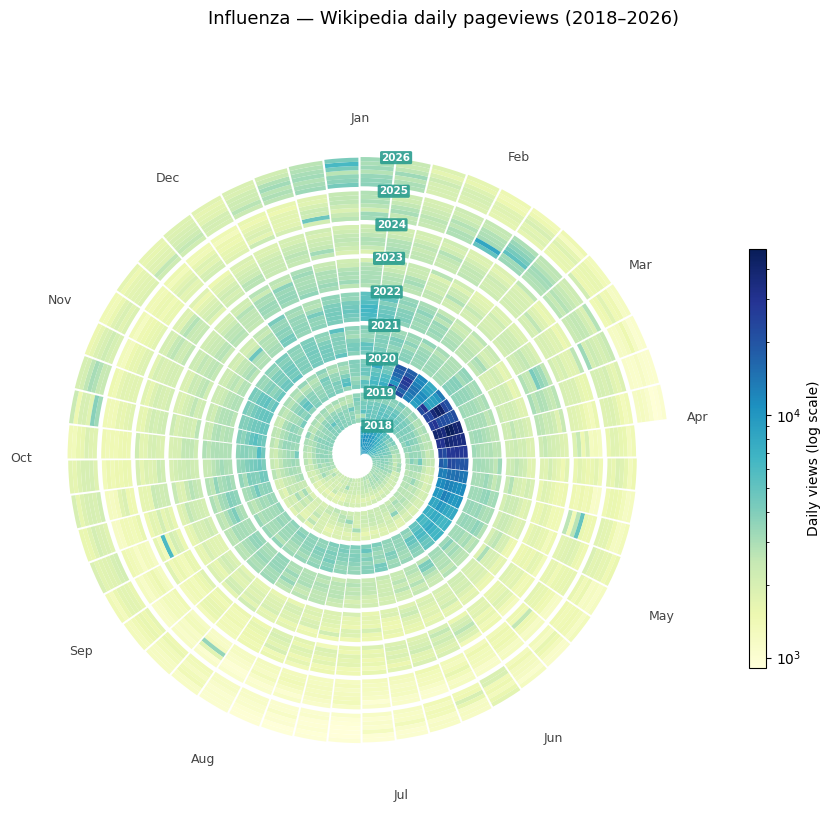

In [2]:
influenza = fetch_pageviews("Influenza", "2018-01-01", "2026-03-26")

fig, ax = plot_spiral(
    influenza,
    title="Influenza — Wikipedia daily pageviews (2018–2026)",
    log_scale=True,
    colourbar_label="Daily views (log scale)",
)
plt.show()

## 2. Kayaking — summer seasonality (opposite phase)

Views peak every **May–August** as people plan outdoor activities.
The dark arc lands at the opposite side of the circle from Influenza,
illustrating how the spiral immediately reveals the phase of a seasonal pattern.

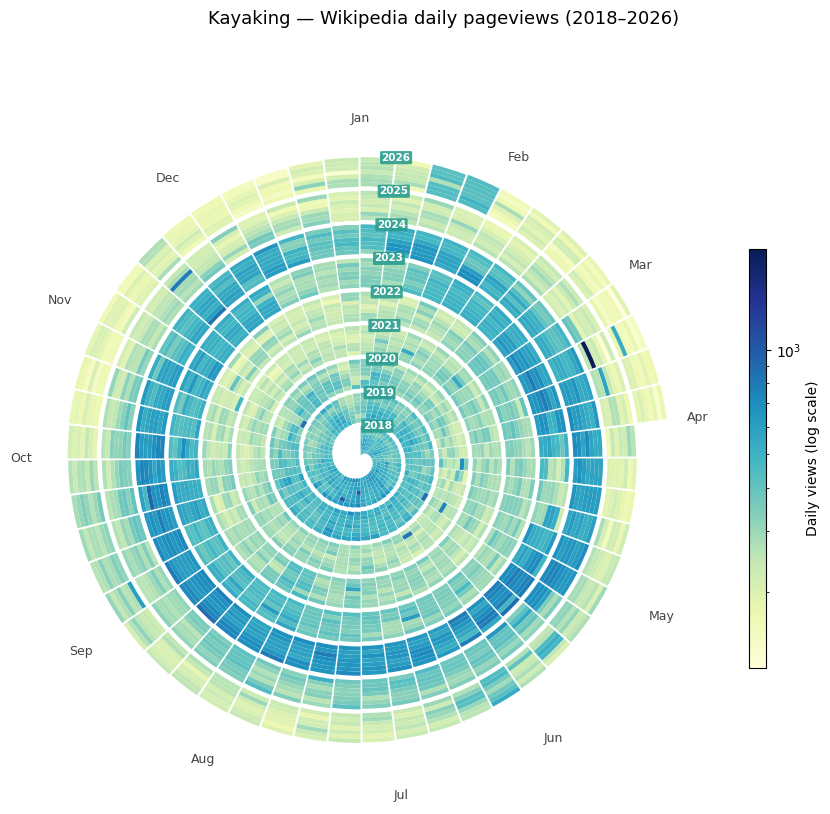

In [3]:
kayaking = fetch_pageviews("Kayaking", "2018-01-01", "2026-03-26")

fig, ax = plot_spiral(
    kayaking,
    title="Kayaking — Wikipedia daily pageviews (2018–2026)",
    log_scale=True,
    colourbar_label="Daily views (log scale)",
)
plt.show()

## 3. Game of Thrones — episodic event-driven spikes

A very different pattern: rather than a smooth seasonal gradient, traffic
spikes sharply when each series airs and collapses between seasons.

| Series | Air dates | Angular position |
|--------|-----------|------------------|
| S1–S6  | April–June | 3–5 o'clock |
| S7     | July–August | 5–7 o'clock |
| S8     | April–May 2019 | 3–4 o'clock |

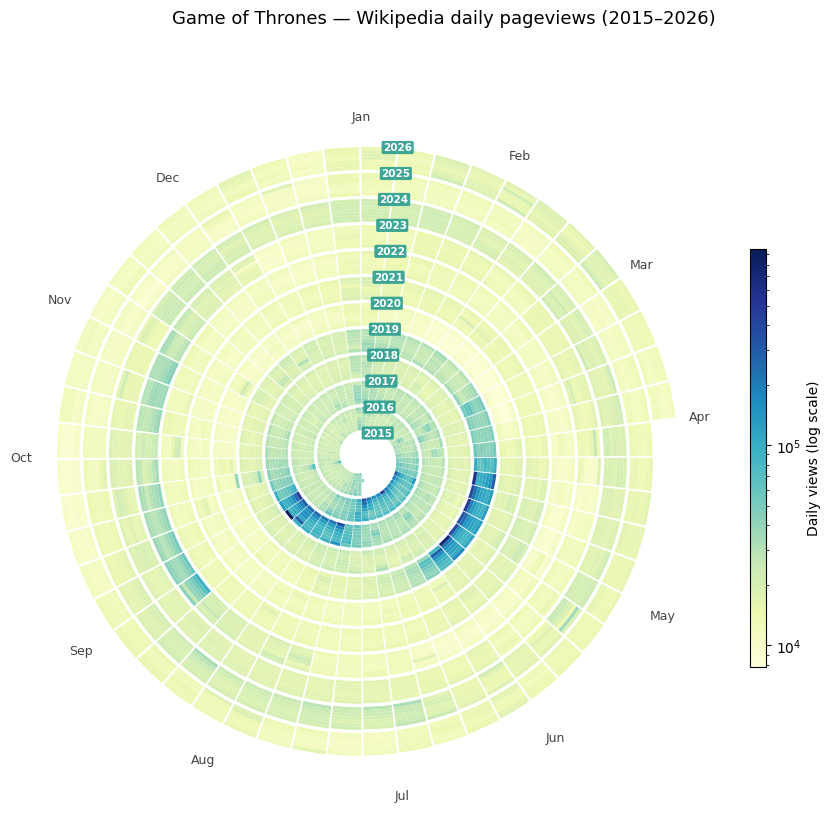

In [4]:
got = fetch_pageviews("Game_of_Thrones", "2015-01-01", "2026-03-26")

fig, ax = plot_spiral(
    got,
    title="Game of Thrones — Wikipedia daily pageviews (2015–2026)",
    log_scale=True,
    colourbar_label="Daily views (log scale)",
)
plt.show()

## 4. Sourdough — structural break from COVID-19

Traffic was unremarkable until the March–April 2020 lockdowns triggered
a baking surge, visible as a sudden bright arc in the 2020 ring that
then gradually settles to a permanently higher baseline.

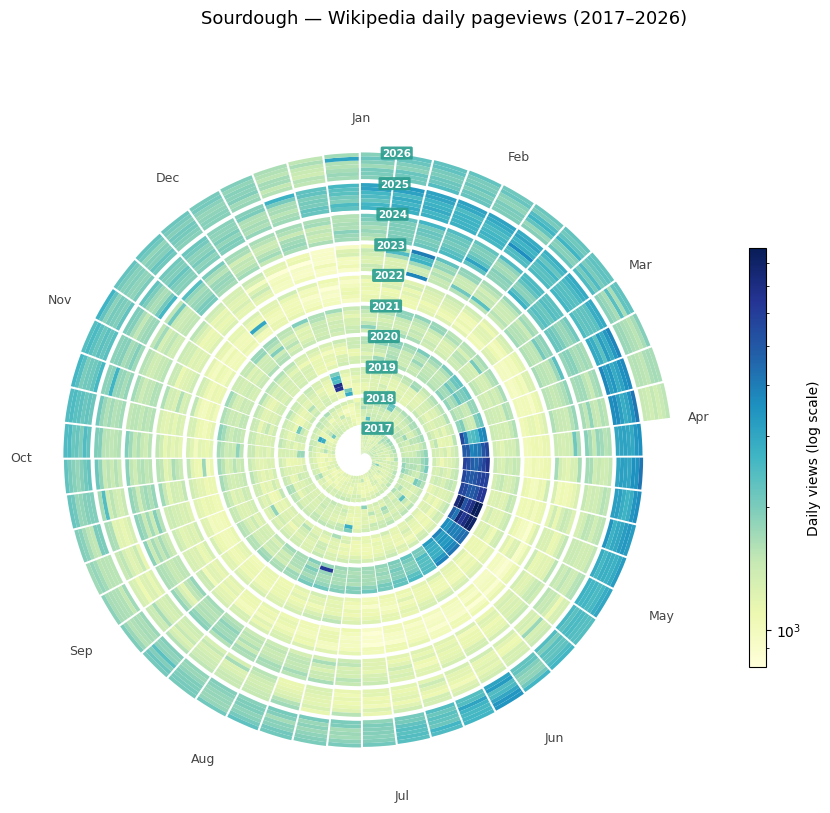

In [5]:
sourdough = fetch_pageviews("Sourdough", "2017-01-01", "2026-03-26")

fig, ax = plot_spiral(
    sourdough,
    title="Sourdough — Wikipedia daily pageviews (2017–2026)",
    log_scale=True,
    colourbar_label="Daily views (log scale)",
)
plt.show()

## 5. Side-by-side comparison: contrasting seasonality

Placing two spirals side by side makes the phase difference immediately obvious
even without reading any axis labels.

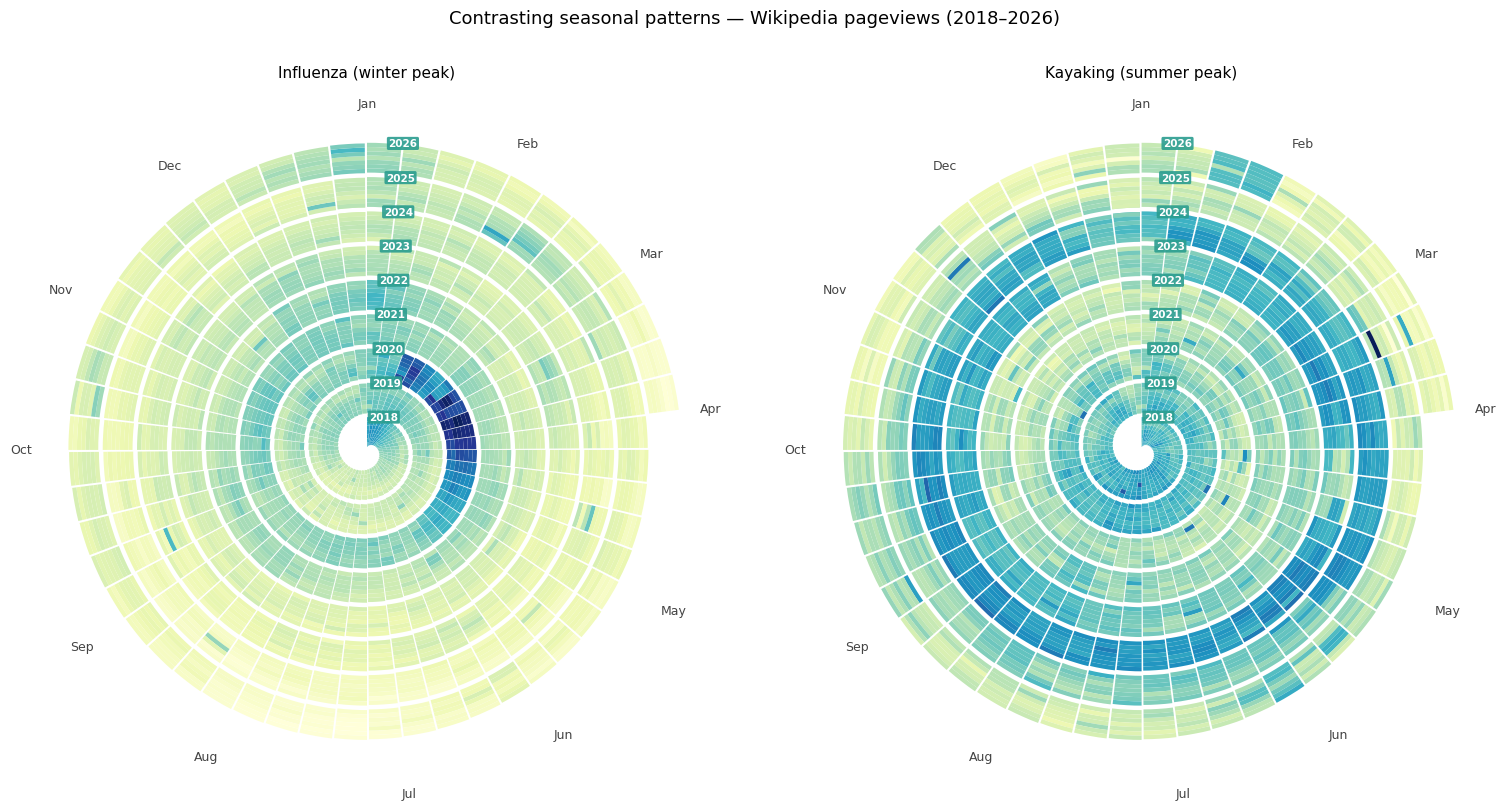

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for data, ax, title in [
    (influenza, axes[0], "Influenza (winter peak)"),
    (kayaking,  axes[1], "Kayaking (summer peak)"),
]:
    SeasonalSpiral(data, log_scale=True).plot(
        ax=ax, colourbar=False
    )
    ax.set_title(title, pad=15, fontsize=11)

fig.suptitle(
    "Contrasting seasonal patterns — Wikipedia pageviews (2018–2026)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## 6. Interactive version (Plotly)

Hover over any tile to see the exact date, pageview count, and day of week.

In [7]:
fig = plot_spiral_interactive(
    influenza,
    title="Influenza — Wikipedia daily pageviews (2018–2026)",
    log_scale=True,
    colourbar_label="Daily views (log scale)",
)
fig.show()